# Character GPT

Srinidhi, SID4 2342. This notebook defaults to **CPU smoke verification**. Its small synthetic outputs are not final lab results. Review the source and configuration before full training. Every run writes raw logs, provenance, metrics, outputs, and checkpoints to a new folder.

In [1]:
SID4 = 2342
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10
print(dict(SID4=SID4, SEED=SEED, SLICE=SLICE, HP_ID=HP_ID, CLS_A=CLS_A, CLS_B=CLS_B))

{'SID4': 2342, 'SEED': 2342, 'SLICE': 342, 'HP_ID': 2, 'CLS_A': 2, 'CLS_B': 3}


In [2]:
from pathlib import Path
import os
import sys
roots = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in roots if (p / "src/lab1").is_dir() and (p / "pyproject.toml").is_file()), None)
if ROOT is None:
    raise RuntimeError("Extract the complete package and start this notebook inside its folder.")
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
from lab1.common import environment, utc_now
from lab1.run import execute
print(environment())

{'captured_utc': '2026-09-18T22:31:21.284988+00:00', 'python': '3.12.14', 'platform': 'macOS-27.0-arm64-arm-64bit', 'machine': 'arm64', 'packages': {'torch': '2.11.0', 'torchvision': '0.26.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'scipy': '1.16.3', 'matplotlib': '3.11.2', 'datasets': '5.0.1', 'Pillow': '12.3.0', 'clean-fid': '0.1.35', 'lpips': '0.1.4', 'prdc': '0.2'}, 'cuda_available': False, 'cuda_build': None, 'cudnn': None, 'gpus': [], 'mps_available': True}


In [3]:
TASK = "gpt"
MODE = "smoke"  # "rehearsal" is short; "full" selects the complete training configuration.
DEVICE = "cpu"  # Change to "cuda" on RunPod or the college NVIDIA machine.
OVERRIDES = []  # See task README for actual image-data paths and optional overrides.
OUTPUT = Path("reproducibility/raw_logs/srinidhi") / ("notebook-" + MODE + "-" + utc_now().replace(":", "-")) / TASK
print({"task": TASK, "mode": MODE, "device": DEVICE, "output": str(OUTPUT)})

{'task': 'gpt', 'mode': 'smoke', 'device': 'cpu', 'output': 'reproducibility/raw_logs/srinidhi/notebook-smoke-2026-09-18T22-31-21.299149+00-00/gpt'}


In [4]:
result = execute(TASK, MODE, OUTPUT, DEVICE, overrides=OVERRIDES)
result["summary"]

{"event": "start", "task": "gpt", "mode": "smoke", "utc": "2026-09-18T22:31:21.315161+00:00", "device": "cpu"}


{"event": "completed", "task": "gpt", "mode": "smoke", "elapsed_seconds": 1.3556434160054778}


{'task': 'character_gpt',
 'mode': 'smoke',
 'is_final_training_run': False,
 'status': 'limited_rehearsal_not_final_results',
 'dataset': 'synthetic smoke fixture',
 'manifest_sha256': '4d0824e968a0cb1e2a3d253eb40b1809fd7b7d9aa8ca78381e45a8e404767ee4',
 'train_stories': 8,
 'validation_stories': 4,
 'train_windows_per_epoch': 24,
 'train_targets_per_epoch': 655,
 'validation_windows': 12,
 'vocabulary_size': 35,
 'validation_unknown_characters': 4,
 'validation_character_count': 323,
 'metric_note': 'Character metrics include EOS targets and map unseen validation characters to UNK',
 'parameter_count': 28736,
 'device': 'cpu',
 'device_name': 'CPU',
 'torch_version': '2.11.0',
 'numpy_version': '2.5.3',
 'cuda_version': None,
 'mixed_precision': False,
 'precision_dtype': 'torch.float32',
 'resume_scaler_status': 'not_resumed',
 'completed_full_epochs': 1,
 'global_steps': 6,
 'planned_steps': 6,
 'best_validation_cross_entropy': 3.4545700586534784,
 'best_checkpoint_epoch': 1,
 'best

figures/learning_curves.png


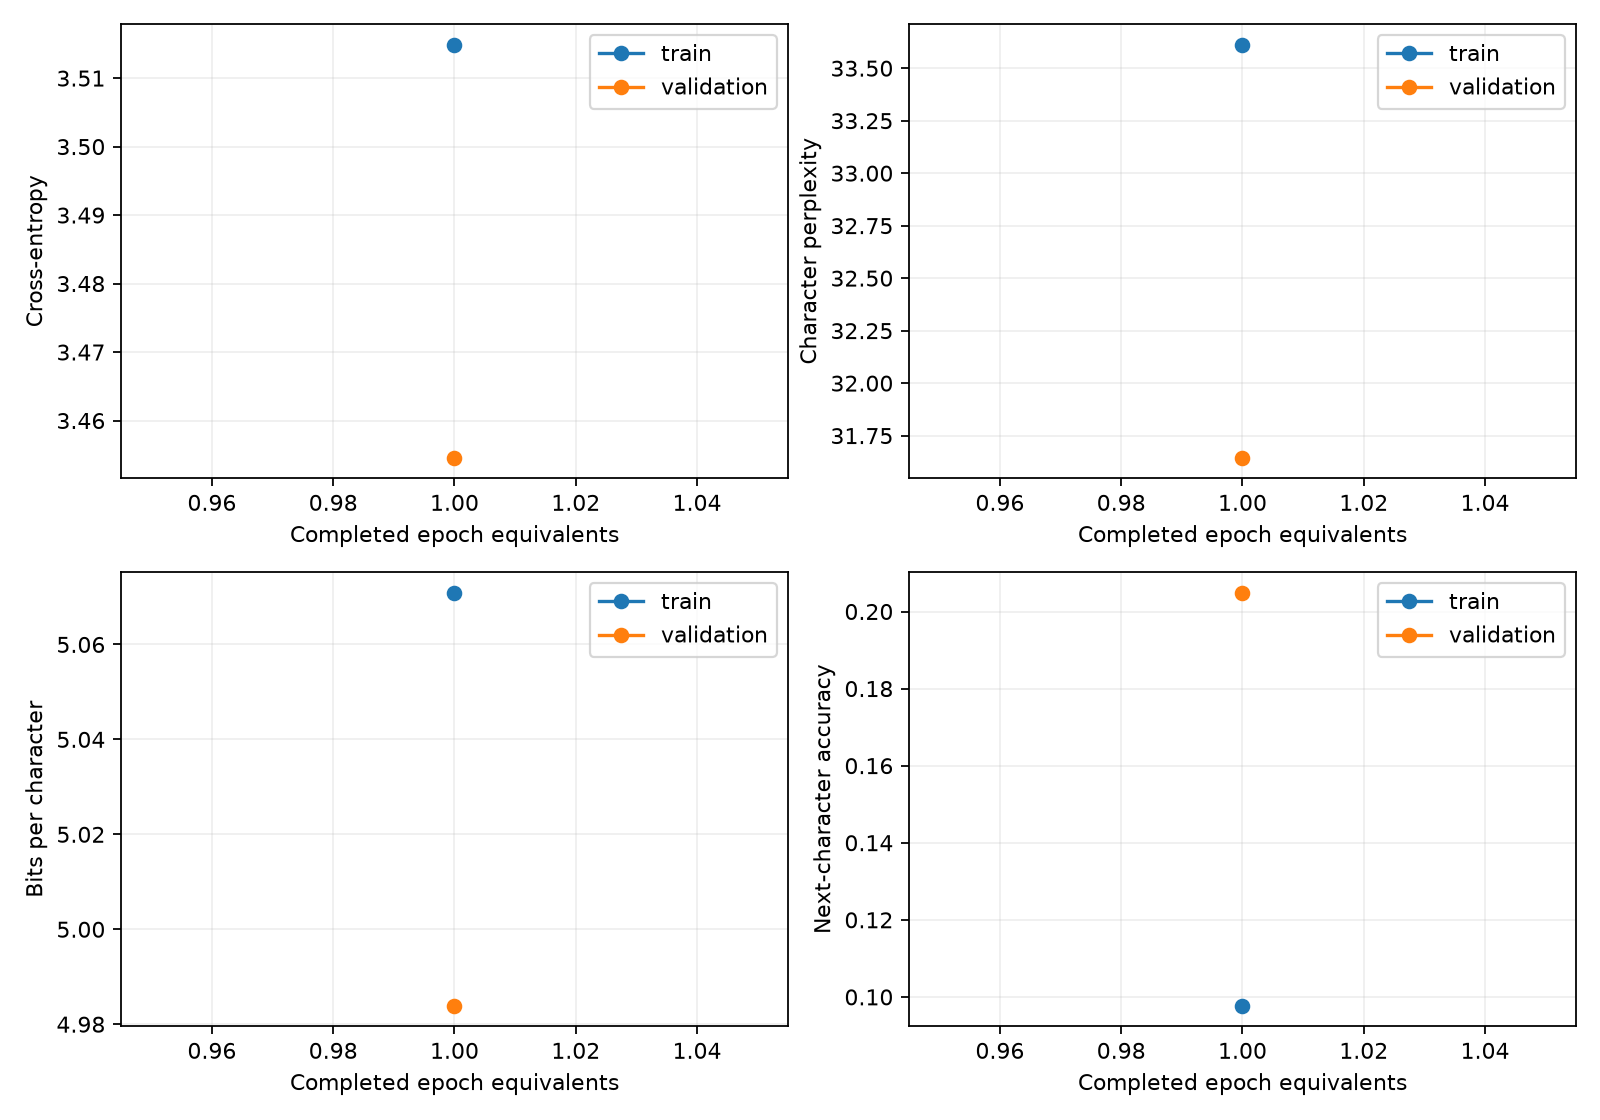

figures/training_diagnostics.png


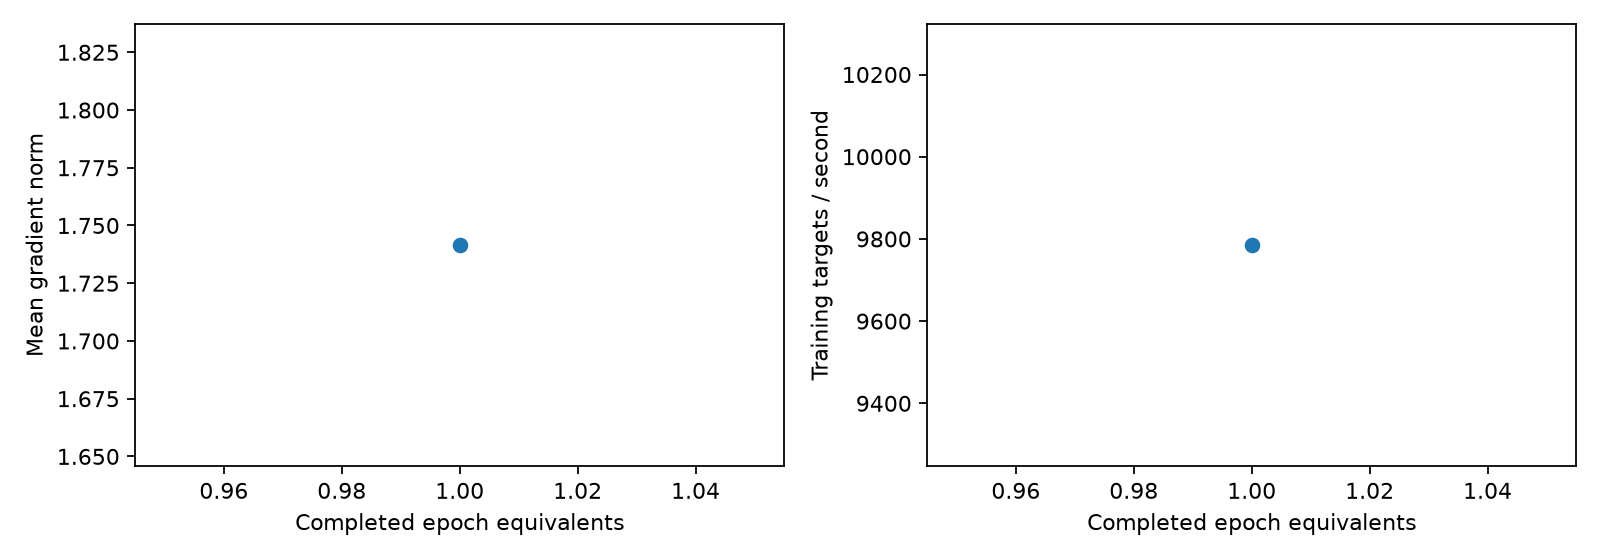

Artifacts:
RUN_LOG.txt
config.json
data_manifest.json
failure_analysis.md
figures/learning_curves.png
figures/training_diagnostics.png
generations.json
history.json
metrics.jsonl
provenance/2026-09-18T22-31-21.303821+00-00.json
resolved_config.json
run_summary.json
summary.json
vocabulary.json


In [5]:
from IPython.display import display, Image
figures = sorted(p for p in OUTPUT.rglob("*.png") if p.is_file() and
                 (TASK != "cyclegan" or "grids" in p.relative_to(OUTPUT).parts))
for path in figures:
    print(path.relative_to(OUTPUT))
    display(Image(filename=str(path), width=700))
print("Artifacts:")
for path in sorted(OUTPUT.rglob("*")):
    if path.is_file() and path.suffix not in {".pt", ".pth"}:
        print(path.relative_to(OUTPUT))

## Interpretation to write after the real run

Explain the architecture and hyperparameters in your own words. Report the actual data split and hardware. Use generated evidence for metrics and failure analysis. Keep smoke, cloud rehearsal, and college full-run results separate. For the team report, compare all members on the agreed evaluation protocol.